In [85]:
from langchain.agents import create_agent
from langchain_openrouter import ChatOpenRouter
from langgraph.graph import StateGraph,START,END
from typing_extensions import TypedDict
from typing import Literal
import os
from tools import *
load_dotenv()
env_key = os.getenv("OPENROUTER_API_KEY")

In [86]:
class State(TypedDict):
    message: str

In [94]:
llm = ChatOpenRouter(
    model = "inclusionai/ling-3.0-flash:free",
    temperature = 0.7,
    openrouter_api_key = env_key
)

search_products_agent = create_agent(
    model = llm,
    tools = [search_products_tool],
)

fetch_product_rating_agent = create_agent(
    model = llm,
    tools = [fetch_product_rating_tool],
)

checkout_agent = create_agent(
    model = llm,
    tools = [checkout_tool]
)

In [95]:
def router_one(state: State) -> Literal["fetch_product_rating", "checkout"]:
    msg = state["messages"][-1].content.lower()
    product_fetch_keywords = ["rating", "ratings", "review", "reviews", "stars", "score", "good", "feedback"]
    checkout_keywords = ["buy", "purchase", "order", "checkout", "check out", "place order"]

    product_fetch_condition = False
    for i in product_fetch_keywords:
        if i in msg:
            product_fetch_condition = True
            break

    checkout_condition = False
    for i in checkout_keywords:
        if i in msg:
            checkout_condition = True
            break

    if product_fetch_condition and checkout_condition:
        return "fetch_product_rating"
    elif product_fetch_condition:
        return "fetch_product_rating"
    elif checkout_condition:
        return "checkout"

In [96]:
def router_two(state: State) -> Literal["checkout"]:
    msg = state["messages"][-1].content.lower()
    checkout_keywords = ["buy", "purchase", "order", "checkout", "check out", "place order"]

    checkout_condition = False
    for i in checkout_keywords:
        if i in msg:
            checkout_condition = True
            break

    if checkout_condition:
        return "checkout"
    else:
        return "end"

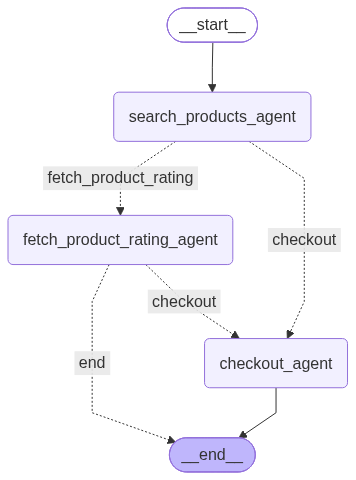

In [99]:
graph = StateGraph(State)


graph.add_node("search_products_agent",search_products_agent)
graph.add_node("fetch_product_rating_agent",fetch_product_rating_agent)
graph.add_node("checkout_agent",checkout_agent)


graph.add_edge(START,"search_products_agent")
graph.add_conditional_edges(
    source="search_products_agent",
    path=router_one,
    path_map={
        "fetch_product_rating": "fetch_product_rating_agent",
        "checkout": "checkout_agent"
    })
graph.add_conditional_edges(
    source="fetch_product_rating_agent",
    path=router_two,
    path_map={
        "checkout" : "checkout_agent",
        "end" : END
    })
graph.add_edge("checkout_agent",END)

full_graph = graph.compile()
full_graph

In [100]:
user_input = """
I would like to order Orange Blossom Honey.
"""

result = full_graph.invoke(
    input =  {"messages": [{"role": "user", "content" : user_input}]}
)

BadRequestResponseError: Input required: specify "prompt" or "messages"

In [52]:
print(result["messages"][-1].content)

Here are all the honey products available:

| # | Name | Description | Price | Organic |
|---|------|-------------|-------|---------|
| 1 | **Organic Raw Honey** | Pure organic raw honey, unfiltered and cold-pressed | $14.99 | ✅ Yes |
| 2 | **Wildflower Honey** | Natural wildflower honey from local beekeepers | $12.99 | ❌ No |
| 3 | **Organic Manuka Honey** | Premium organic Manuka honey from New Zealand | $29.99 | ✅ Yes |
| 4 | **Clover Honey** | Classic clover honey, smooth and sweet | $8.99 | ❌ No |
| 5 | **Organic Buckwheat Honey** | Dark and robust organic buckwheat honey, antioxidant-rich | $18.99 | ✅ Yes |
| 6 | **Orange Blossom Honey** | Light and floral orange blossom honey | $15.99 | ❌ No |
| 7 | **Organic Acacia Honey** | Light and mild organic acacia honey, low glycemic index | $17.99 | ✅ Yes |
| 8 | **Creamed Honey** | Smooth creamed honey with spreadable texture | $11.99 | ❌ No |

A total of **8 honey products** were found, with **4 organic** and **4 non-organic** options